In [1]:
import numpy as np
from scipy.sparse.linalg import eigsh

from tqdm import tqdm 

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize


import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from loaders import movielens

## Collaboration

In [22]:
def plot_relative_matrix(
    A,
    row_labels=None,
    col_labels=None,
    cmap_red='Reds',
    cmap_green='Greens',
    figsize=(8, 8)
):
    """
    Visualize a square matrix with off-diagonal coloring based on difference
    from diagonal elements of each row, and optional row/column labels.

    Parameters
    ----------
    A : np.ndarray
        Square matrix to visualize.
    row_labels : list[str] or list[int], optional
        Labels for rows. Defaults to range(n).
    col_labels : list[str] or list[int], optional
        Labels for columns. Defaults to range(n).
    """

    A = np.asarray(A)
    assert A.ndim == 2 and A.shape[0] == A.shape[1], "Matrix must be square"
    n = A.shape[0]

    # Default labels
    if row_labels is None:
        row_labels = list(range(n))
    if col_labels is None:
        col_labels = list(range(n))

    assert len(row_labels) == n and len(col_labels) == n, \
        "Row and column labels must have length equal to matrix dimension"

    # Differences relative to row diagonal
    row_diag = np.diag(A).reshape(-1, 1)
    diff = A - row_diag

    # Normalize by max absolute off-diagonal difference
    off_diag_mask = ~np.eye(n, dtype=bool)
    max_diff = np.max(np.abs(diff[off_diag_mask]))
    if max_diff == 0:
        max_diff = 1.0
    norm = Normalize(vmin=0, vmax=max_diff)

    fig, ax = plt.subplots(figsize=figsize)

    # Background
    ax.imshow(np.zeros_like(A), cmap='gray', vmin=0, vmax=1)

    # Fill each cell manually
    for i in range(n):
        for j in range(n):
            if i == j:
                color = "white"
            else:
                d = diff[i, j]
#                 intensity = norm(abs(d))
                intensity = abs(d)
    
                if d > 0:
                    color = plt.cm.get_cmap(cmap_green)(intensity)
                elif d < 0:
                    color = plt.cm.get_cmap(cmap_red)(intensity)
                else:
                    color = "white"

            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, facecolor=color))

            # Annotate numeric value
            ax.text(j, i, f"{A[i,j]:.2f}", ha="center", va="center", fontsize=10)

    # Tick settings
    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(col_labels, rotation=45, ha='right')
    ax.set_yticklabels(row_labels)

    # Axes limits
    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(n - 0.5, -0.5)

    ax.set_aspect("equal")
    ax.set_title("Matrix Visualization (Relative to Diagonal)")
    plt.tight_layout()
    plt.show()


In [13]:
def get_train_test_X(X, p):
    rng = np.random.default_rng()
    
    # Find all non-zero positions
    nz_rows, nz_cols = np.nonzero(X)
    nz_indices = list(zip(nz_rows, nz_cols))
    
    total_nz = len(nz_indices)
    k = int(np.floor(p * total_nz))

    # Random subset of indices
    chosen = rng.choice(total_nz, size=k, replace=False)
    
    # Masks
    mask_p = np.zeros(total_nz, dtype=bool)
    mask_p[chosen] = True
    
    # Prepare output matrices
    X_train = np.zeros_like(X)
    X_test = np.zeros_like(X)
    
    # Fill in p% split
    for i, (r, c) in enumerate(nz_indices):
        if mask_p[i]:
            X_train[r, c] = X[r, c]
        else:
            X_test[r, c] = X[r, c]
    
    return csr_matrix(X_train), csr_matrix(X_test)

In [14]:
movielens_obj = movielens.movielens(
    min_ratings = 1,
    min_users = 200,
    binary=True, 
    data_dir="../data/")

label_to_idxs = movielens_obj.get_user_labels("Age")

X = movielens_obj.get_X()
X_train, X_test = get_train_test_X(X, p=0.8)

assert np.sum(X > 0) == np.sum(X_train > 0) + np.sum(X_test > 0)

idx_to_metadata = movielens_obj.get_movie_metadata()
movie_title_to_idx = {
    metadata["title"]: idx 
    for idx, metadata in idx_to_metadata.items()
}

Shape before filtering:  (6040, 3706)
Shape after filtering:  (6040, 1426)


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/6026 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/6026 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/6026 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/6026 [00:00<?, ?it/s]

Text(0.5, 1.0, 'MAP@K')

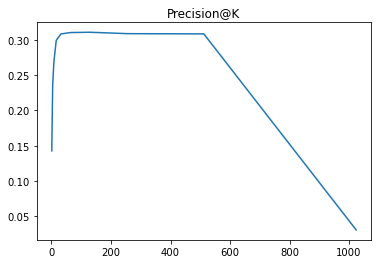

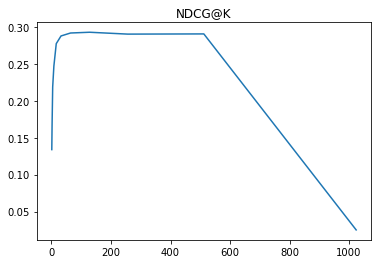

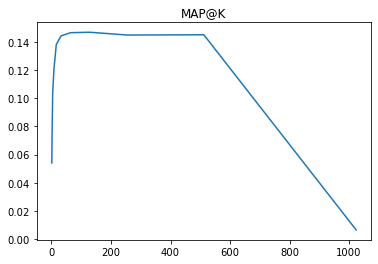

In [21]:
from implicit.gpu import bpr
from implicit.evaluation import ranking_metrics_at_k
from scipy.sparse import csr_matrix

rs = [2**i for i in range(11)]

precs = []
ndcgs = []
maps = []

for r in rs:
    bpr_model = bpr.BayesianPersonalizedRanking(factors=r)
    bpr_model.fit(X_train, show_progress=True)
    
    ranking_metrics = ranking_metrics_at_k(bpr_model, X_train, X_test, K=20)

    precs.append(ranking_metrics["precision"])
    ndcgs.append(ranking_metrics["ndcg"])
    maps.append(ranking_metrics["map"])
    
fig, ax = plt.subplots()
ax.plot(rs, precs)
ax.set_title("Precision@K")

fig, ax = plt.subplots()
ax.plot(rs, ndcgs)
ax.set_title("NDCG@K")

fig, ax = plt.subplots()
ax.plot(rs, maps)
ax.set_title("MAP@K")


In [28]:
labels = [label for label in label_to_idxs]
g = len(labels)
r = 32
rng = np.random.default_rng(seed=0)

group_by_group_prec = np.zeros((g, g))
group_by_group_ndcg = np.zeros((g, g))
group_by_group_map = np.zeros((g, g))

for i, label_i in enumerate(labels):    
    for j, label_j in tqdm(enumerate(labels)):        
        train_row_idxs = label_to_idxs[label_i]
        if j != i:
            train_row_idxs = np.concatenate((
                label_to_idxs[label_i],
                label_to_idxs[label_j]
#                 rng.choice(
#                     label_to_idxs[label_j], 
#                     size = len(label_to_idxs[label_i]),
#                     replace = True)
            ))
            
        X_train_subset = X_train[train_row_idxs]
        X_test_subset = X_test[label_to_idxs[label_i]]
        
        bpr_model = bpr.BayesianPersonalizedRanking(factors=r)
        bpr_model.fit(X_train_subset)

        ranking_metrics = ranking_metrics_at_k(bpr_model, 
                                               X_train_subset, 
                                               X_test_subset, 
                                               K=20)

        group_by_group_prec[i, j] = ranking_metrics["precision"]
        group_by_group_ndcg[i, j] = ranking_metrics["ndcg"]
        group_by_group_map[i, j] = ranking_metrics["map"]


0it [00:00, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/221 [00:00<?, ?it/s]

1it [00:00,  2.01it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/377 [00:00<?, ?it/s]

6it [00:03,  1.90it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/377 [00:00<?, ?it/s]

7it [00:03,  1.87it/s]


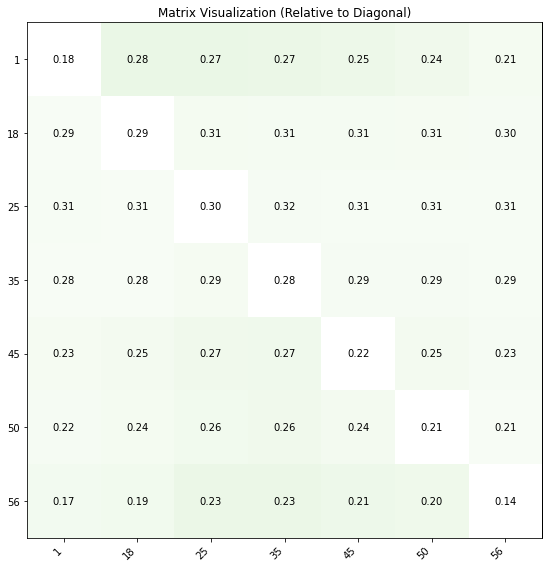

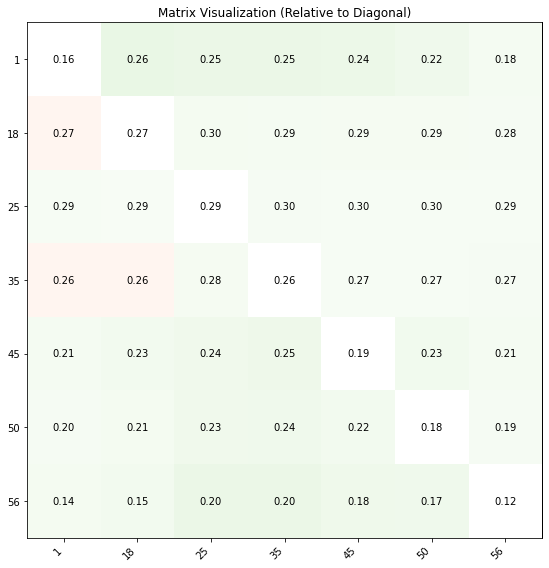

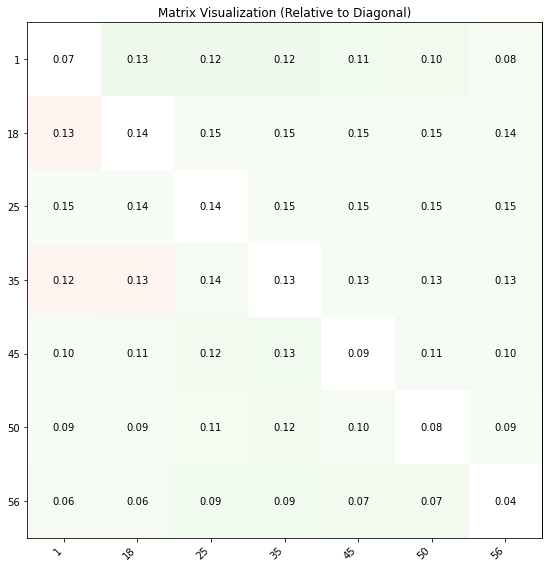

In [29]:
plot_relative_matrix(group_by_group_prec, 
                    row_labels=labels,
                    col_labels=labels)

plot_relative_matrix(group_by_group_ndcg, 
                    row_labels=labels,
                    col_labels=labels)

plot_relative_matrix(group_by_group_map, 
                    row_labels=labels,
                    col_labels=labels)

## Misrepresentation